# M2-B2 — Audit éthique Athéna RH — phase SYNC binôme

> **Mission** : audit éthique complet du dataset Adult Income enrichi de
> commentaires manager. Datasheet duo signée. La phase d'anonymisation
> personnelle se fera en async (notebook séparé).

Binôme : `Tom` + `Romain` — Date : `17/06/2026`

**Conventions** :
- `random_state=42` partout
- Pas de `print` (utiliser `display()` ou laisser la cellule retourner)
- `pathlib.Path` sur les chemins

## 0. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path("../data")
FULL_PATH = DATA_DIR / "adult_income_with_comments.csv"
SAMPLE_PATH = DATA_DIR / "audit_sample.csv"

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv(FULL_PATH)
print(f"Shape : {df.shape}")
df.head(3)

Shape : (32561, 16)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,manager_comments
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,RAS pour Alexandre Traore cette année. Manager...
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,Entretien annuel de Yves Traore : bon élément....
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,Alerte comportementale signalée par Gabriel de...


## 1. Audit qualité express (~15 min)

Le dataset Adult est plus propre que German Credit (peu de manquants).
Survol express ici — l'audit éthique est le cœur de M2-B2.

In [3]:
display(df.info())
display(
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("manquants")
    .to_frame()
    .query("manquants > 0")
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   age               32561 non-null  int64 
 1   workclass         30725 non-null  object
 2   fnlwgt            32561 non-null  int64 
 3   education         32561 non-null  object
 4   education_num     32561 non-null  int64 
 5   marital_status    32561 non-null  object
 6   occupation        30718 non-null  object
 7   relationship      32561 non-null  object
 8   race              32561 non-null  object
 9   sex               32561 non-null  object
 10  capital_gain      32561 non-null  int64 
 11  capital_loss      32561 non-null  int64 
 12  hours_per_week    32561 non-null  int64 
 13  native_country    31978 non-null  object
 14  income            32561 non-null  object
 15  manager_comments  32561 non-null  object
dtypes: int64(6), object(10)
memory usage: 4.0+ MB


None

,manquants
occupation,1843
workclass,1836
native_country,583


## 2. Audit éthique complet (~1 h)

Calcul du **disparate impact** sur 3 variables sensibles + 1 intersection.

In [4]:
def disparate_impact(df: pd.DataFrame, sensible: str, target: str = "income",
                     positive: str = ">50K") -> tuple[float, pd.Series]:
    """Calcule le DI = SR_min / SR_max + retourne la série des SR par groupe."""
    sr = df.groupby(sensible)[target].apply(lambda x: (x == positive).mean())
    di = sr.min() / sr.max()
    return di, sr

In [5]:
# DI sur sex
di_sex, sr_sex = disparate_impact(df, "sex")

display(
    pd.DataFrame(
        {
            "selection_rate": sr_sex.round(3),
            "n": df.groupby("sex")["income"].count(),
        }
    ).assign(
        DI=di_sex.round(3),
        signal_4_5=lambda _: "NOK" if di_sex < 0.8 else "OK",
    )
)
print(f"DI sex = {di_sex:.3f}")

,selection_rate,n,DI,signal_4_5
sex,,,,
Female,0.109,10771,0.358,NOK
Male,0.306,21790,0.358,NOK


DI sex = 0.358


In [6]:
# DI sur race
di_race, sr_race = disparate_impact(df, "race")

display(
    pd.DataFrame(
        {
            "selection_rate": sr_race.round(3),
            "n": df.groupby("race")["income"].count(),
        }
    )
    .sort_values("selection_rate")
    .assign(
        DI=di_race.round(3),
        signal_4_5=lambda _: "NOK" if di_race < 0.8 else "OK",
    )
)
print(f"DI race = {di_race:.3f}")

,selection_rate,n,DI,signal_4_5
race,,,,
Other,0.092,271,0.347,NOK
Amer-Indian-Eskimo,0.116,311,0.347,NOK
Black,0.124,3124,0.347,NOK
White,0.256,27816,0.347,NOK
Asian-Pac-Islander,0.266,1039,0.347,NOK


DI race = 0.347


In [7]:
# DI sur marital_status
di_marital_status, sr_marital_status = disparate_impact(df, "marital_status")

display(
    pd.DataFrame(
        {
            "selection_rate": sr_marital_status.round(3),
            "n": df.groupby("marital_status")["income"].count(),
        }
    )
    .sort_values("selection_rate")
    .assign(
        DI=di_marital_status.round(3),
        signal_4_5=lambda _: "NOK" if di_marital_status < 0.8 else "OK",
    )
)
print(f"DI marital_status = {di_marital_status:.3f}")

,selection_rate,n,DI,signal_4_5
marital_status,,,,
Never-married,0.046,10683,0.103,NOK
Separated,0.064,1025,0.103,NOK
Married-spouse-absent,0.081,418,0.103,NOK
Widowed,0.086,993,0.103,NOK
Divorced,0.104,4443,0.103,NOK
Married-AF-spouse,0.435,23,0.103,NOK
Married-civ-spouse,0.447,14976,0.103,NOK


DI marital_status = 0.103


In [8]:
# DI sur relationship
di_relationship, sr_relationship = disparate_impact(df, "relationship")

display(
    pd.DataFrame(
        {
            "selection_rate": sr_relationship.round(3),
            "n": df.groupby("relationship")["income"].count(),
        }
    )
    .sort_values("selection_rate")
    .assign(
        DI=di_relationship.round(3),
        signal_4_5=lambda _: "NOK" if di_relationship < 0.8 else "OK",
    )
)
print(f"DI relationship = {di_relationship:.3f}")

,selection_rate,n,DI,signal_4_5
relationship,,,,
Own-child,0.013,5068,0.028,NOK
Other-relative,0.038,981,0.028,NOK
Unmarried,0.063,3446,0.028,NOK
Not-in-family,0.103,8305,0.028,NOK
Husband,0.449,13193,0.028,NOK
Wife,0.475,1568,0.028,NOK


DI relationship = 0.028


In [9]:
# DI sur native_country (agrégé en USA / non-USA pour simplifier)
df["native_us"] = (
    df["native_country"]
    .eq("United-States")
    .map({True: "USA", False: "non-USA"})
)

di_country, sr_country = disparate_impact(df, "native_us")

display(
    pd.DataFrame(
        {
            "selection_rate": sr_country.round(3),
            "n": df.groupby("native_us")["income"].count(),
        }
    ).assign(
        DI=di_country.round(3),
        signal_4_5=lambda _: "NOK" if di_country < 0.8 else "OK",
    )
)
print(f"DI native_country (USA/non-USA) = {di_country:.3f}")

,selection_rate,n,DI,signal_4_5
native_us,,,,
USA,0.246,29170,0.804,OK
non-USA,0.198,3391,0.804,OK


DI native_country (USA/non-USA) = 0.804


In [10]:
results = [
    {
        "variable": "sex",
        "DI": round(di_sex, 3),
        "SR_min": round(sr_sex.min(), 3),
        "SR_max": round(sr_sex.max(), 3),
        "verdict_4/5": "ALERTE" if di_sex < 0.8 else "OK",
    },
    {
        "variable": "race",
        "DI": round(di_race, 3),
        "SR_min": round(sr_race.min(), 3),
        "SR_max": round(sr_race.max(), 3),
        "verdict_4/5": "ALERTE" if di_race < 0.8 else "OK",
    },
    {
        "variable": "marital_status",
        "DI": round(di_marital_status, 3),
        "SR_min": round(sr_marital_status.min(), 3),
        "SR_max": round(sr_marital_status.max(), 3),
        "verdict_4/5": "ALERTE" if di_marital_status < 0.8 else "OK",
    },
    {
        "variable": "relationship",
        "DI": round(di_relationship, 3),
        "SR_min": round(sr_relationship.min(), 3),
        "SR_max": round(sr_relationship.max(), 3),
        "verdict_4/5": "ALERTE" if di_relationship < 0.8 else "OK",
    },
    {
        "variable": "native_country (USA/non-USA)",
        "DI": round(di_country, 3),
        "SR_min": round(sr_country.min(), 3),
        "SR_max": round(sr_country.max(), 3),
        "verdict_4/5": "ALERTE" if di_country < 0.8 else "OK",
    },
]

df_results = pd.DataFrame(results)
display(df_results)

,variable,DI,SR_min,SR_max,verdict_4/5
0,sex,0.358,0.109,0.306,ALERTE
1,race,0.347,0.092,0.266,ALERTE
2,marital_status,0.103,0.046,0.447,ALERTE
3,relationship,0.028,0.013,0.475,ALERTE
4,native_country (USA/non-USA),0.804,0.198,0.246,OK


### Intersectionnalité — DI sur le croisement sex × race

In [11]:
df['sex_race'] = df['sex'].str.cat(df['race'], sep='_')
support = df["sex_race"].value_counts().rename("n_obs")
display(support.to_frame().assign(support_ok=support >= 30))

di_intersect, sr_intersect = disparate_impact(df, "sex_race")

display(
    sr_intersect
    .round(3)
    .sort_values()
    .rename("selection_rate")
    .to_frame()
    .join(support)
    .assign(
        fragile=lambda d: d["n_obs"] < 30,
    )
)
print(f"DI sex × race = {di_intersect:.3f}")
print(
    "Biais d'intersectionalite" if di_intersect < 0.8
    else "OK"
)


,n_obs,support_ok
sex_race,,
Male_White,19174,True
Female_White,8642,True
Male_Black,1569,True
Female_Black,1555,True
Male_Asian-Pac-Islander,693,True
Female_Asian-Pac-Islander,346,True
Male_Amer-Indian-Eskimo,192,True
Male_Other,162,True
Female_Amer-Indian-Eskimo,119,True


,selection_rate,n_obs,fragile
sex_race,,,
Female_Other,0.055,109,False
Female_Black,0.058,1555,False
Female_Amer-Indian-Eskimo,0.101,119,False
Male_Other,0.117,162,False
Female_White,0.119,8642,False
Female_Asian-Pac-Islander,0.124,346,False
Male_Amer-Indian-Eskimo,0.125,192,False
Male_Black,0.189,1569,False
Male_White,0.318,19174,False


DI sex × race = 0.164
Biais d'intersectionalite


## 3. Visualisations (≥ 5)

Au moins 5 visualisations : distribution cible + DI par variable sensible +
crosstab intersection.

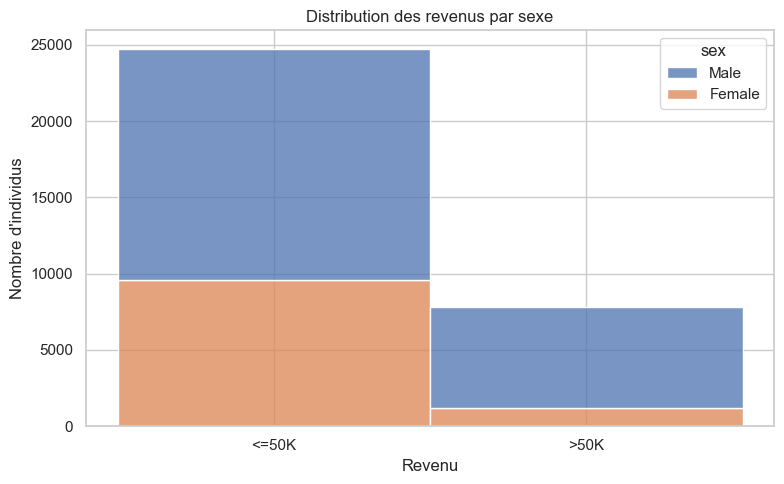

In [12]:
# Distribution de la cible
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="income", hue="sex", multiple="stack")
plt.title("Distribution des revenus par sexe")
plt.xlabel("Revenu")
plt.ylabel("Nombre d'individus")
plt.tight_layout()
plt.show()

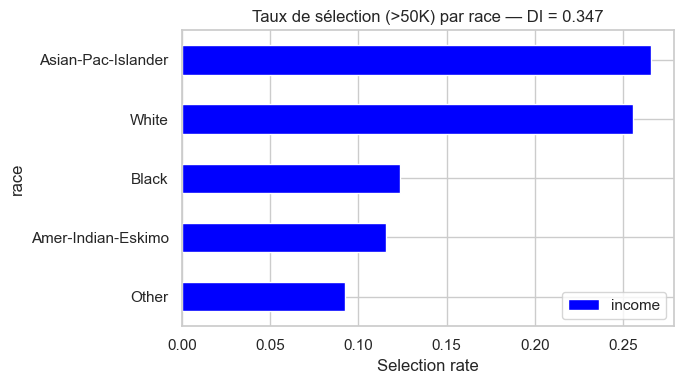

In [13]:
# Taux de sélection par race
fig, ax = plt.subplots(figsize=(7, 4))
sr_race.sort_values().plot(kind="barh", ax=ax, color="blue")
ax.set_title(f"Taux de sélection (>50K) par race — DI = {di_race:.3f}")
ax.set_xlabel("Selection rate")
ax.legend()
plt.tight_layout()
plt.show()

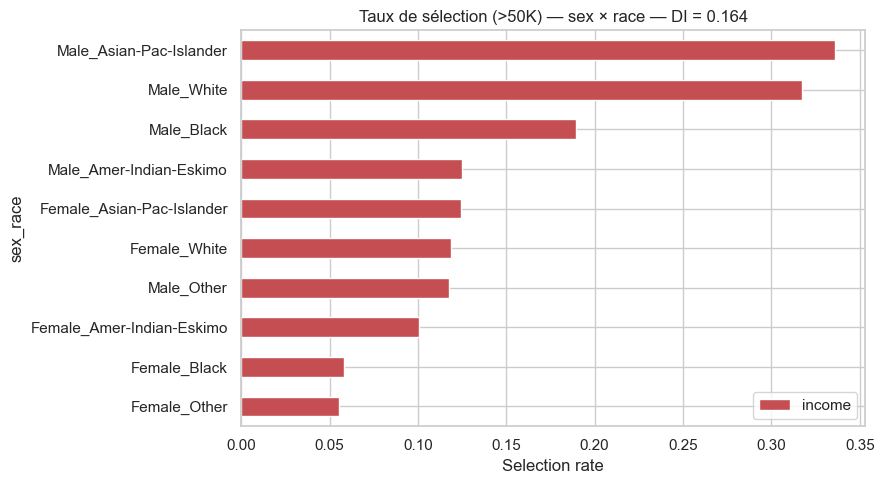

In [14]:
# Taux de sélection par sex × race (intersectionnalité) ---
fig, ax = plt.subplots(figsize=(9, 5))
sr_intersect.sort_values().plot(kind="barh", ax=ax, color="#C44E52")
ax.set_title(
    f"Taux de sélection (>50K) — sex × race — DI = {di_intersect:.3f}"
)
ax.set_xlabel("Selection rate")
ax.legend()
plt.tight_layout()
plt.show()

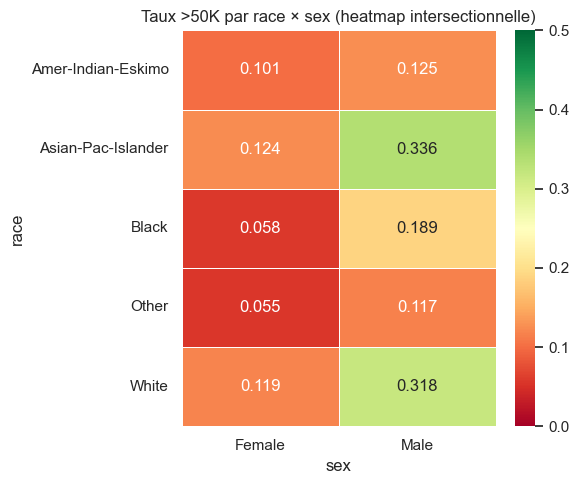

In [15]:
# Heatmap crosstab sex × race
crosstab = pd.crosstab(
    df["race"],
    df["sex"],
    values=(df["income"] == ">50K").astype(int),
    aggfunc="mean",
).round(3)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    crosstab,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    vmin=0,
    vmax=0.5,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Taux >50K par race × sex (heatmap intersectionnelle)")
plt.tight_layout()
plt.show()

## 4. Verdict éthique (paragraphe markdown)

> Court paragraphe : « Quels biais structurels avons-nous détectés ? Quel
> est le DI le plus problématique ? »

À recopier dans `../datasheet.md` (section *Composition* / *Risques*).

## 5. Aperçu de la colonne `manager_comments` (pour préparer l'async)

In [ ]:
# Quelques exemples pour identifier les types de PII
for i in range(5):
    print(f'--- Exemple {i+1} ---')
    print(df['manager_comments'].iloc[i])
    print()

## 6. Datasheet binôme (à compléter dans `../datasheet.md`)

Reprendre la structure Gebru — 7 sections, 2 pages max. Signée duo
(« Auteurs : <prénom1>, <prénom2> » en haut).